**Data Description:**


The file Bank.xls contains data on 5000 customers. The data include customer demographic information (age, income, etc.), the customer's relationship with the bank (mortgage, securities account, etc.), and the customer response to the last personal loan campaign (Personal Loan). Among these 5000 customers, only 480 (= 9.6%) accepted the personal loan that was offered to them in the earlier campaign.


**Domain:**


Banking

**Context:**


This case is about a bank (Thera Bank) whose management wants to explore ways of converting its liability customers to personal loan customers (while retaining them as depositors). A campaign that the bank ran last year for liability customers showed a healthy conversion rate of over 9% success. This has encouraged the retail marketing department to devise campaigns with better target marketing to increase the success ratio with minimal budget.

# 1. Importing Necessary Libraries

In [0]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
from sklearn.preprocessing import scale
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn import metrics
from sklearn.neighbors import KNeighborsClassifier
from sklearn import svm
plt.show()
sns.set()
%matplotlib inline
from sklearn.naive_bayes import GaussianNB

Upload CSV File to Google Colab

In [0]:
from google.colab import files

uploaded = files.upload()

Saving Bank_Personal_Loan_Modelling.csv to Bank_Personal_Loan_Modelling (1).csv


**Basic EDA :**

In [0]:
data = pd.read_csv("Bank_Personal_Loan_Modelling.csv")
data.head()

,ID,Age,Experience,Income,ZIP Code,Family,CCAvg,Education,Mortgage,Personal Loan,Securities Account,CD Account,Online,CreditCard
0,1,25,1,49,91107,4,1.6,1,0,0,1,0,0,0
1,2,45,19,34,90089,3,1.5,1,0,0,1,0,0,0
2,3,39,15,11,94720,1,1.0,1,0,0,0,0,0,0
3,4,35,9,100,94112,1,2.7,2,0,0,0,0,0,0
4,5,35,8,45,91330,4,1.0,2,0,0,0,0,0,1


In [0]:
data.shape

(5000, 14)

In [0]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 14 columns):
ID                    5000 non-null int64
Age                   5000 non-null int64
Experience            5000 non-null int64
Income                5000 non-null int64
ZIP Code              5000 non-null int64
Family                5000 non-null int64
CCAvg                 5000 non-null float64
Education             5000 non-null int64
Mortgage              5000 non-null int64
Personal Loan         5000 non-null int64
Securities Account    5000 non-null int64
CD Account            5000 non-null int64
Online                5000 non-null int64
CreditCard            5000 non-null int64
dtypes: float64(1), int64(13)
memory usage: 547.0 KB


In [0]:
data.isnull().sum()

ID                    0
Age                   0
Experience            0
Income                0
ZIP Code              0
Family                0
CCAvg                 0
Education             0
Mortgage              0
Personal Loan         0
Securities Account    0
CD Account            0
Online                0
CreditCard            0
dtype: int64

In [0]:
data.describe().T

,count,mean,std,min,25%,50%,75%,max
ID,5000.0,2500.500000,1443.520003,1.0,1250.75,2500.5,3750.25,5000.0
Age,5000.0,45.338400,11.463166,23.0,35.00,45.0,55.00,67.0
Experience,5000.0,20.104600,11.467954,-3.0,10.00,20.0,30.00,43.0
Income,5000.0,73.774200,46.033729,8.0,39.00,64.0,98.00,224.0
ZIP Code,5000.0,93152.503000,2121.852197,9307.0,91911.00,93437.0,94608.00,96651.0
Family,5000.0,2.396400,1.147663,1.0,1.00,2.0,3.00,4.0
CCAvg,5000.0,1.937938,1.747659,0.0,0.70,1.5,2.50,10.0
Education,5000.0,1.881000,0.839869,1.0,1.00,2.0,3.00,3.0
Mortgage,5000.0,56.498800,101.713802,0.0,0.00,0.0,101.00,635.0
Personal Loan,5000.0,0.096000,0.294621,0.0,0.00,0.0,0.00,1.0


In [0]:
data.skew()

ID                     0.000000
Age                   -0.029341
Experience            -0.026325
Income                 0.841339
ZIP Code             -12.500221
Family                 0.155221
CCAvg                  1.598443
Education              0.227093
Mortgage               2.104002
Personal Loan          2.743607
Securities Account     2.588268
CD Account             3.691714
Online                -0.394785
CreditCard             0.904589
dtype: float64

Among these 5000 customers, only 480 (= 9.6%) accepted the personal loan that 

was offered to them in the earlier campaign.

In [0]:

data.groupby('Personal Loan').count()

,ID,Age,Experience,Income,ZIP Code,Family,CCAvg,Education,Mortgage,Securities Account,CD Account,Online,CreditCard
Personal Loan,,,,,,,,,,,,,
0,4520,4520,4520,4520,4520,4520,4520,4520,4520,4520,4520,4520,4520
1,480,480,480,480,480,480,480,480,480,480,480,480,480


Distribution of each Feature in the Data Set

No handles with labels found to put in legend.


<Figure size 7200x7200 with 0 Axes>

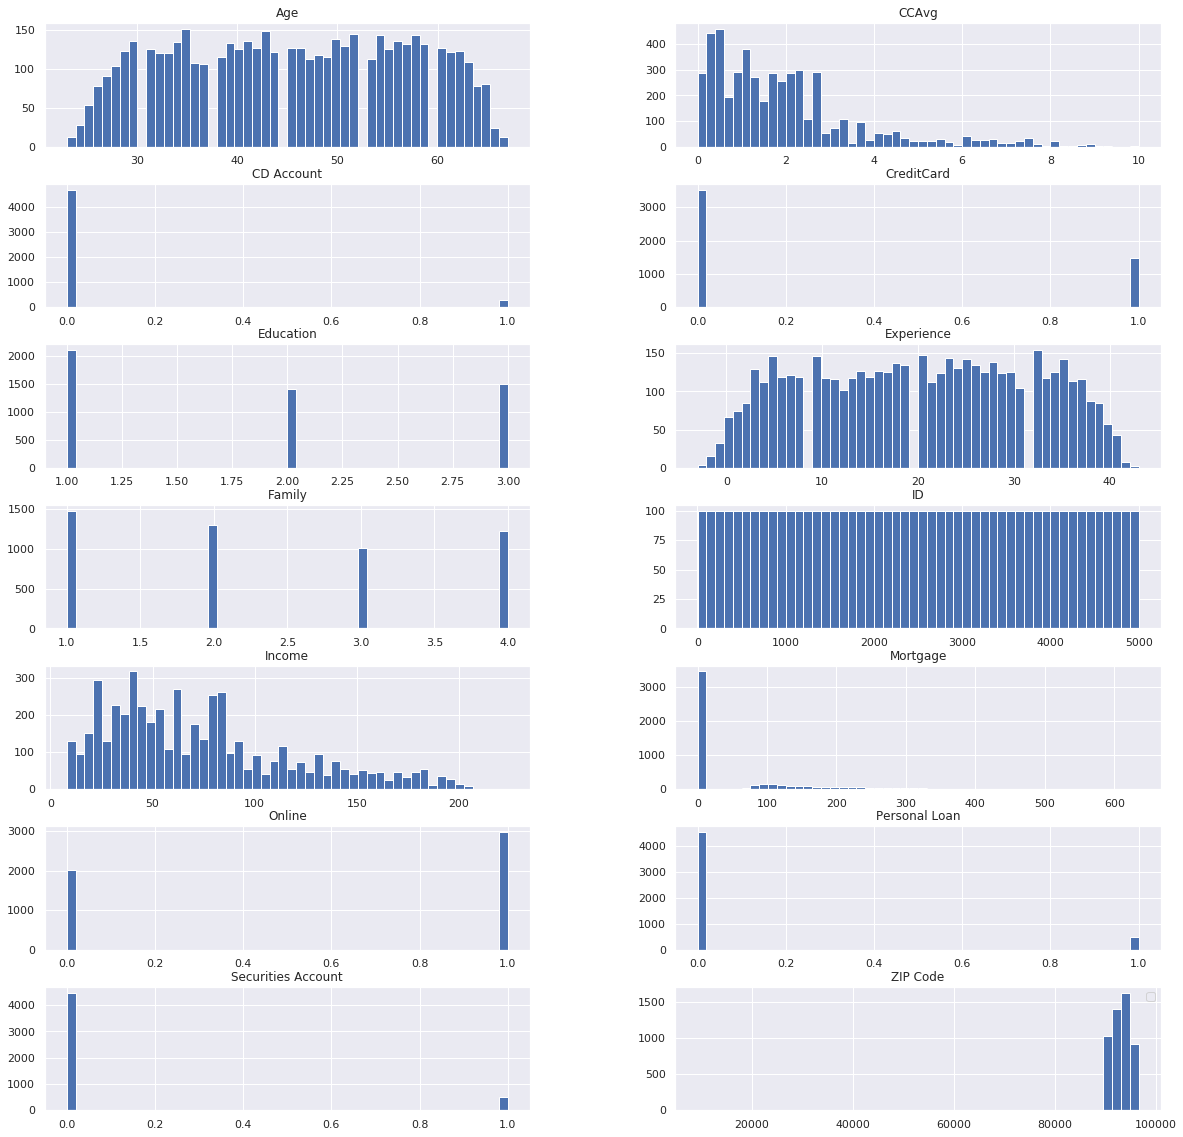

In [0]:
plt.figure(figsize=(100,100))

data.hist(figsize=(20,20), layout=(7,2), bins=50)

plt.legend()

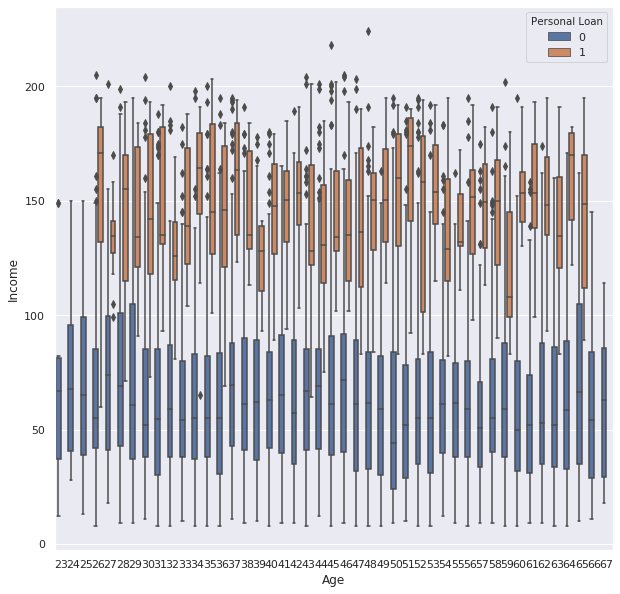

In [0]:
plt.figure(figsize=(10,10))

sns.boxplot('Age','Income',hue='Personal Loan',data=data)

Finding Outliers in Age, Income & Target Column

In [0]:
for column in data[['Age','Income','Personal Loan']]:
    val = column
    q1 = data[val].quantile(0.25)
    q3 = data[val].quantile(0.75)
    iqr = q3-q1
    fence_low  = q1-(1.5*iqr)
    fence_high = q3+(1.5*iqr)
    df_out = data.loc[(data[val] < fence_low) | (data[val] > fence_high)]
    if df_out.empty:
        print('No Outliers in the ' + val + ' column of given dataset')
    else:
        print('There are Outliers in the ' + val + ' column of given dataset')

No Outliers in the Age column of given dataset
There are Outliers in the Income column of given dataset
There are Outliers in the Personal Loan column of given dataset


In [0]:
corr = data.corr()
corr

,ID,Age,Experience,Income,ZIP Code,Family,CCAvg,Education,Mortgage,Personal Loan,Securities Account,CD Account,Online,CreditCard
ID,1.000000,-0.008473,-0.008326,-0.017695,0.013432,-0.016797,-0.024675,0.021463,-0.013920,-0.024801,-0.016972,-0.006909,-0.002528,0.017028
Age,-0.008473,1.000000,0.994215,-0.055269,-0.029216,-0.046418,-0.052012,0.041334,-0.012539,-0.007726,-0.000436,0.008043,0.013702,0.007681
Experience,-0.008326,0.994215,1.000000,-0.046574,-0.028626,-0.052563,-0.050077,0.013152,-0.010582,-0.007413,-0.001232,0.010353,0.013898,0.008967
Income,-0.017695,-0.055269,-0.046574,1.000000,-0.016410,-0.157501,0.645984,-0.187524,0.206806,0.502462,-0.002616,0.169738,0.014206,-0.002385
ZIP Code,0.013432,-0.029216,-0.028626,-0.016410,1.000000,0.011778,-0.004061,-0.017377,0.007383,0.000107,0.004704,0.019972,0.016990,0.007691
Family,-0.016797,-0.046418,-0.052563,-0.157501,0.011778,1.000000,-0.109275,0.064929,-0.020445,0.061367,0.019994,0.014110,0.010354,0.011588
CCAvg,-0.024675,-0.052012,-0.050077,0.645984,-0.004061,-0.109275,1.000000,-0.136124,0.109905,0.366889,0.015086,0.136534,-0.003611,-0.006689
Education,0.021463,0.041334,0.013152,-0.187524,-0.017377,0.064929,-0.136124,1.000000,-0.033327,0.136722,-0.010812,0.013934,-0.015004,-0.011014
Mortgage,-0.013920,-0.012539,-0.010582,0.206806,0.007383,-0.020445,0.109905,-0.033327,1.000000,0.142095,-0.005411,0.089311,-0.005995,-0.007231
Personal Loan,-0.024801,-0.007726,-0.007413,0.502462,0.000107,0.061367,0.366889,0.136722,0.142095,1.000000,0.021954,0.316355,0.006278,0.002802


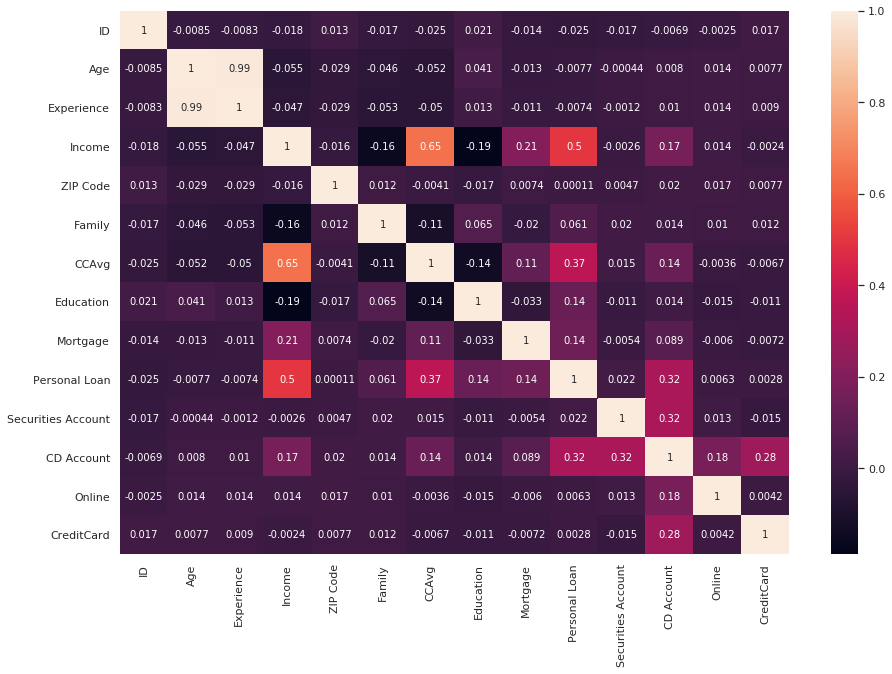

In [0]:
plt.figure(figsize=(15,10))

sns.heatmap(corr, annot=True)

<Figure size 720x720 with 0 Axes>

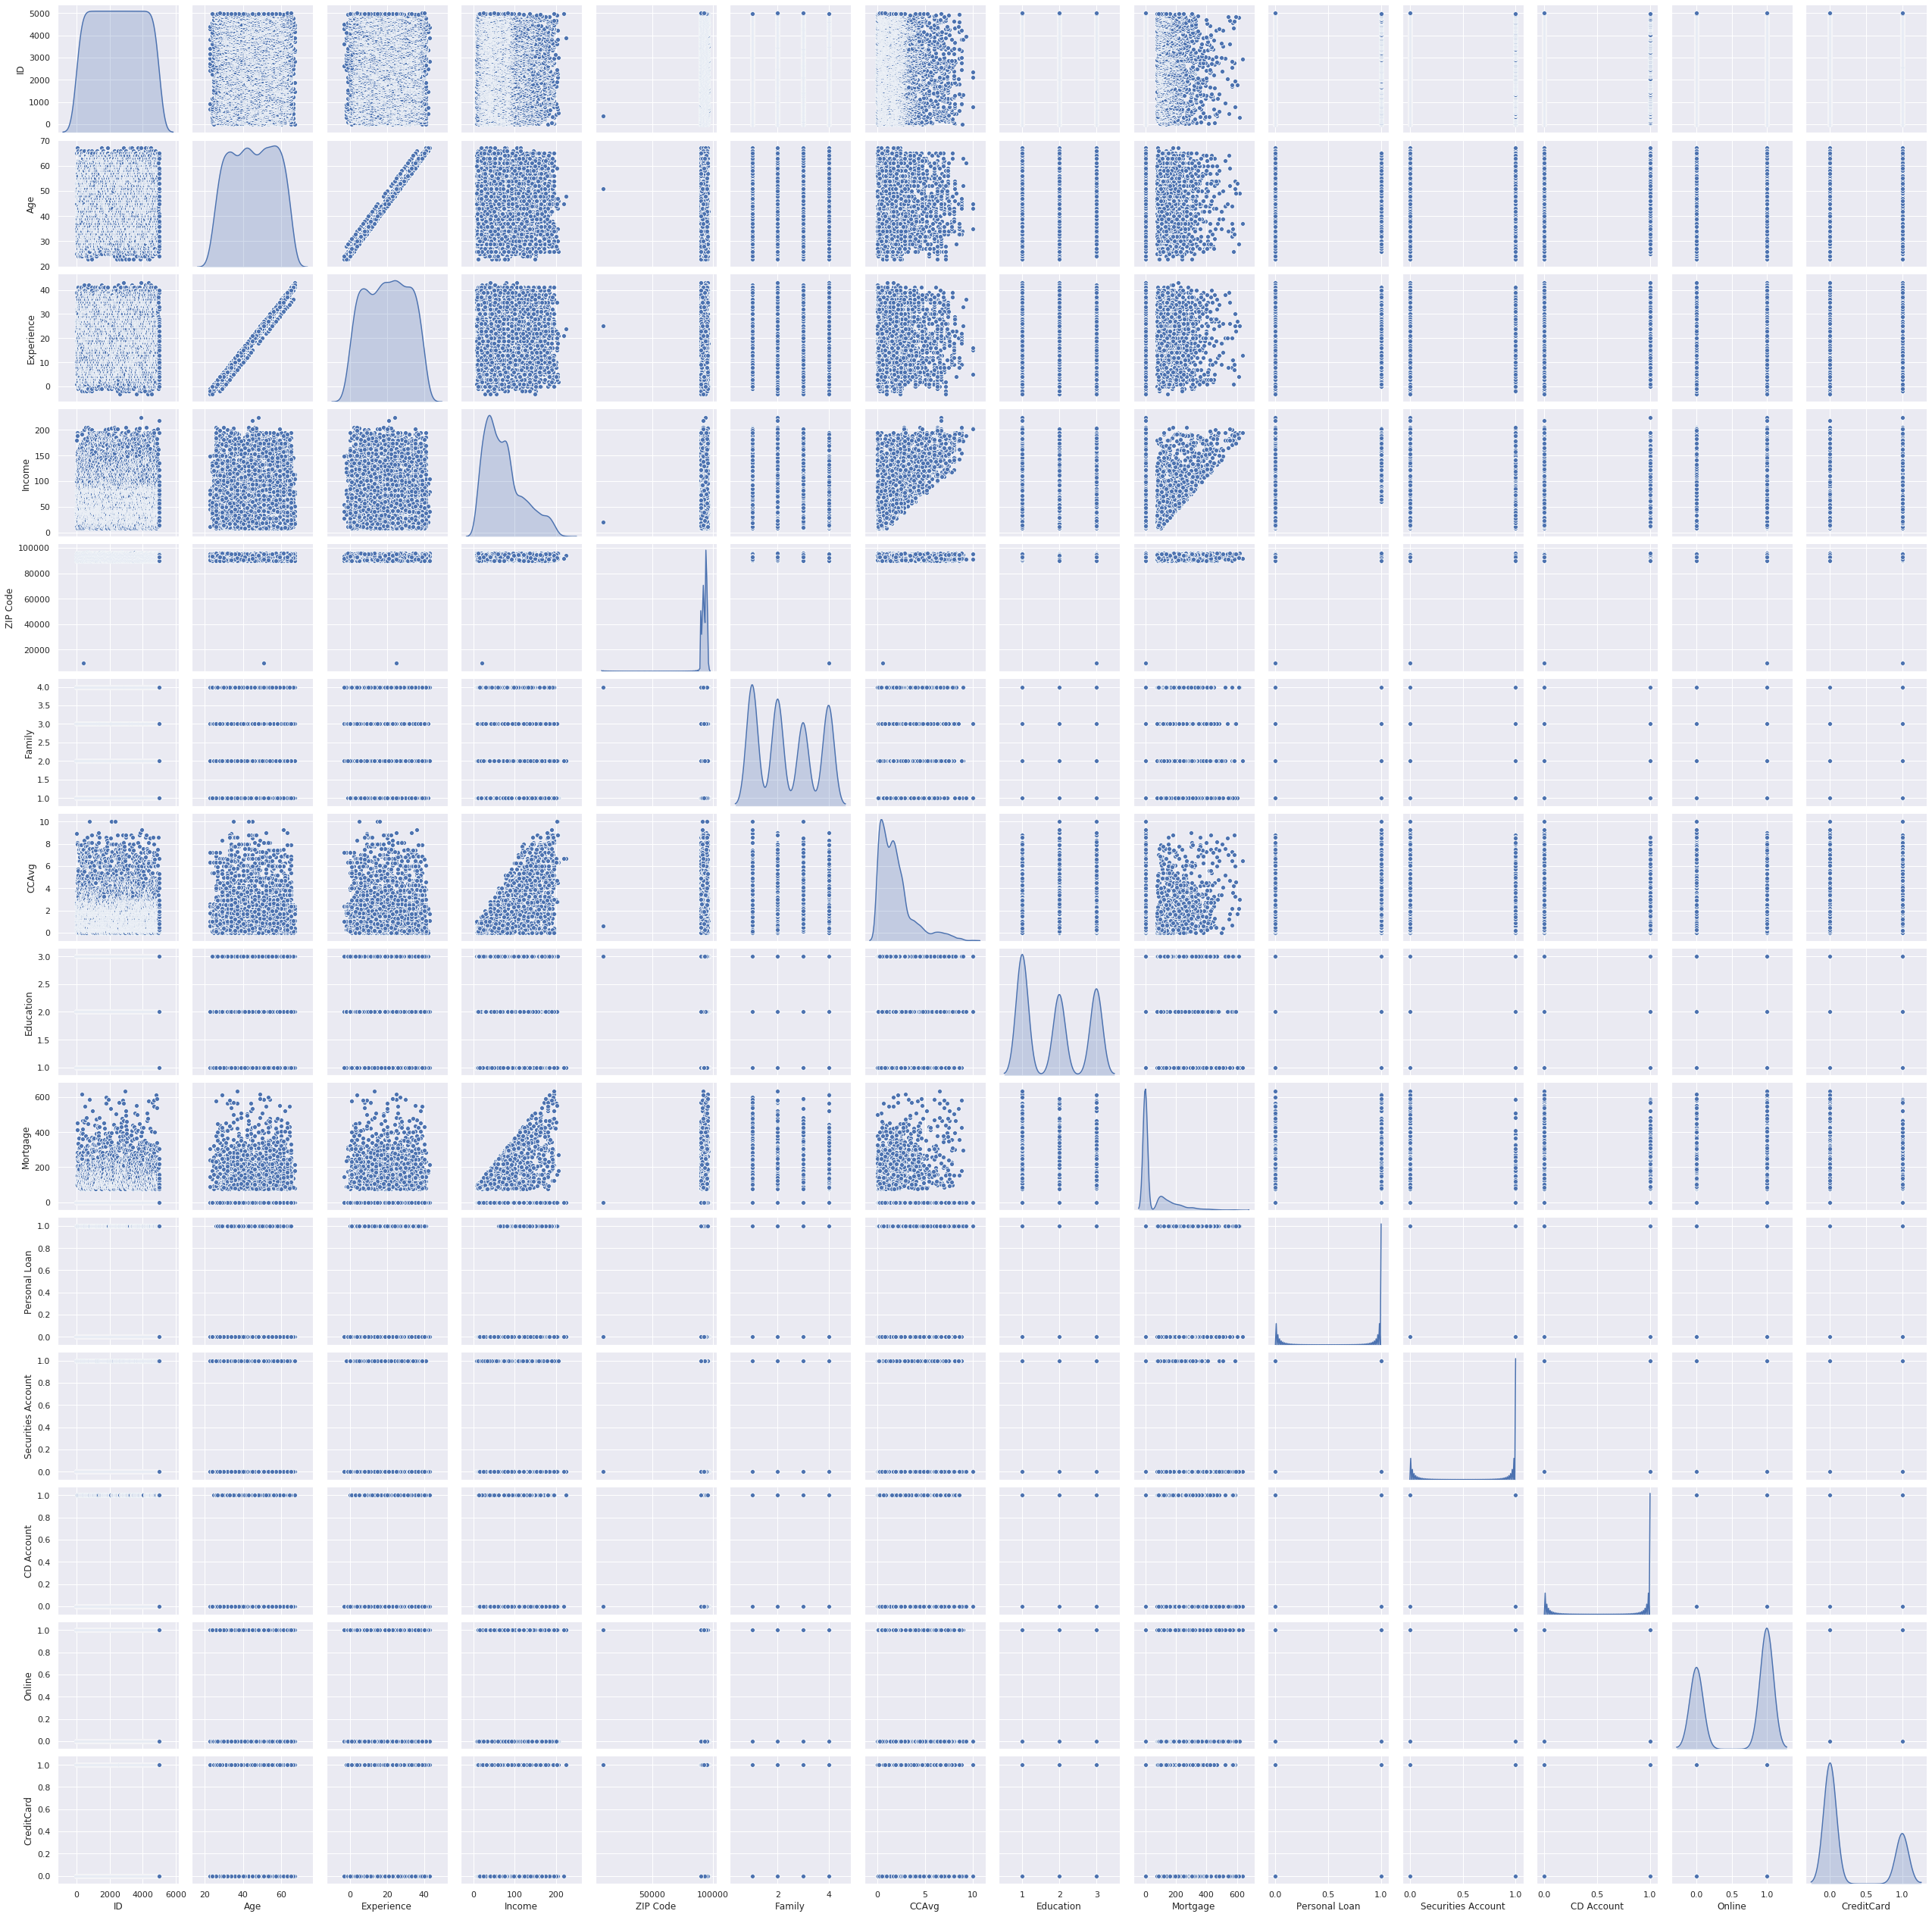

In [0]:

plt.figure(figsize=(10,10))

sns.pairplot(data, kind='scatter', diag_kind='kde')

Below Scatter Plots shows that Target Colummn values are mostly linear classified.

AxesSubplot(0.125,0.125;0.775x0.755)


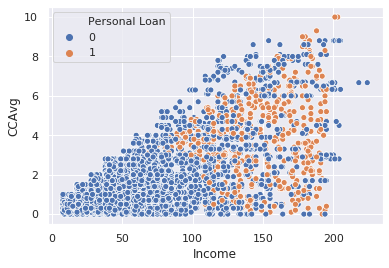

In [0]:
print(sns.scatterplot('Income', 'CCAvg', data=data, hue='Personal Loan'))

AxesSubplot(0.125,0.125;0.775x0.755)


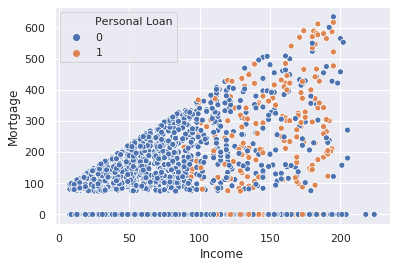

In [0]:
print(sns.scatterplot('Income', 'Mortgage', data=data, hue='Personal Loan'))

AxesSubplot(0.125,0.125;0.775x0.755)


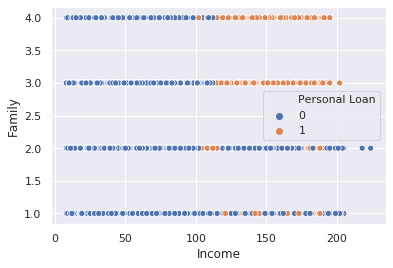

In [0]:
print(sns.scatterplot('Income', 'Family', data=data, hue='Personal Loan'))

AxesSubplot(0.125,0.125;0.775x0.755)


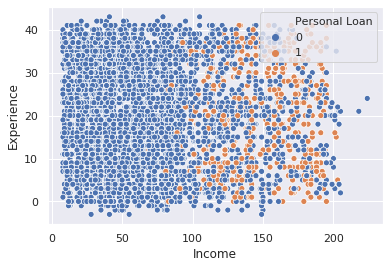

In [0]:
print(sns.scatterplot('Income', 'Experience', data=data, hue='Personal Loan'))

In [0]:
data[['Income', 'CCAvg', 'Mortgage']] = data[['Income', 'CCAvg', 'Mortgage']] * 1000

In [0]:
data.head()

,ID,Age,Experience,Income,ZIP Code,Family,CCAvg,Education,Mortgage,Personal Loan,Securities Account,CD Account,Online,CreditCard
0,1,25,1,49000,91107,4,1600.0,1,0,0,1,0,0,0
1,2,45,19,34000,90089,3,1500.0,1,0,0,1,0,0,0
2,3,39,15,11000,94720,1,1000.0,1,0,0,0,0,0,0
3,4,35,9,100000,94112,1,2700.0,2,0,0,0,0,0,0
4,5,35,8,45000,91330,4,1000.0,2,0,0,0,0,0,1


Eliminating the features which may create misclassification 

In [0]:
data.drop(columns=['ID', 'Age', 'Experience', 'ZIP Code', 'Online'], axis=1, inplace=True)

In [0]:
data.head()

,Income,Family,CCAvg,Education,Mortgage,Personal Loan,Securities Account,CD Account,CreditCard
0,49000,4,1600.0,1,0,0,1,0,0
1,34000,3,1500.0,1,0,0,1,0,0
2,11000,1,1000.0,1,0,0,0,0,0
3,100000,1,2700.0,2,0,0,0,0,0
4,45000,4,1000.0,2,0,0,0,0,1


In [0]:
No_of_Credit_Card_True = len(data.loc[data['CreditCard'] == True])
No_of_Credit_Card_True

1470

In [0]:
No_of_Credit_Card_False = len(data.loc[data['CreditCard'] == False])
No_of_Credit_Card_False

3530

In [0]:
X = data.drop('Personal Loan', axis=1)
Y = data[['Personal Loan']].astype('category')

In [0]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.30, random_state=10)

**Logistic Algorithm**

/usr/local/lib/python3.6/dist-packages/sklearn/utils/validation.py:760: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/usr/local/lib/python3.6/dist-packages/sklearn/utils/validation.py:760: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


Accuracy of the Model=95.33
              precision    recall  f1-score   support

           0       0.96      0.99      0.98      1360
           1       0.87      0.60      0.71       140

    accuracy                           0.95      1500
   macro avg       0.91      0.80      0.84      1500
weighted avg       0.95      0.95      0.95      1500



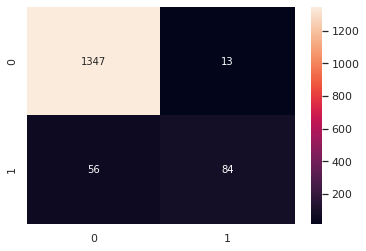

In [0]:
log = LogisticRegression()

X_train = scale(X_train)
X_test = scale(X_test)


log.fit(X_train, Y_train)

Log_Ypred = log.predict(X_test)

log.fit(X_test, Y_test)

Log_Train_Score = log.score(X_train, Y_train)
Log_Test_Score = log.score(X_test, Y_test)

Log_CM = metrics.confusion_matrix(Y_test, Log_Ypred)

print("Accuracy of the Model=%.2f" %(Log_Test_Score*100))

sns.heatmap(Log_CM, annot=True, fmt='1g')

Log_CR_Report = metrics.classification_report(Y_test, Log_Ypred)

print(Log_CR_Report)

ROC & AUC Curve Plot

Shows Good AUC Area

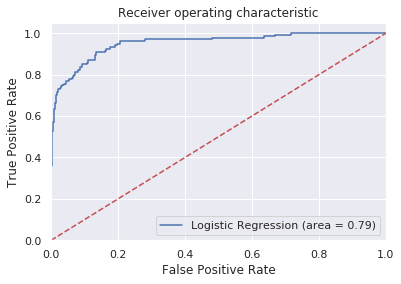

In [0]:
from sklearn.metrics import roc_auc_score
from sklearn.metrics import roc_curve

logit_roc_auc = roc_auc_score(Y_test, log.predict(X_test))
fpr, tpr, thresholds = roc_curve(Y_test, log.predict_proba(X_test)[:,1])
plt.figure()
plt.plot(fpr, tpr, label='Logistic Regression (area = %0.2f)' % logit_roc_auc)
plt.plot([0, 1], [0, 1],'r--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver operating characteristic')
plt.legend(loc="lower right")
plt.savefig('Log_ROC')
plt.show()

**KNN Algorithm**

/usr/local/lib/python3.6/dist-packages/ipykernel_launcher.py:3: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  This is separate from the ipykernel package so we can avoid doing imports until


KNN Classification Report
               precision    recall  f1-score   support

           0       0.98      1.00      0.99      1360
           1       0.96      0.78      0.86       140

    accuracy                           0.98      1500
   macro avg       0.97      0.89      0.92      1500
weighted avg       0.98      0.98      0.98      1500

AxesSubplot(0.125,0.125;0.62x0.755)

Accuracy of Trainingset=1.00

Accuracy of Testset=0.98


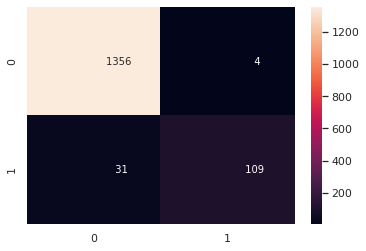

In [0]:
KNN = KNeighborsClassifier(n_neighbors = 3, weights = 'distance', algorithm='kd_tree')

KNN.fit(X_train, Y_train)



KNN_Ypred = KNN.predict(X_test)

KNN_Train_Score = KNN.score(X_train, Y_train)
KNN_Test_Score = KNN.score(X_test, Y_test)

KNN_CM = metrics.confusion_matrix(Y_test, KNN_Ypred)

KNN_CR_Report = metrics.classification_report(Y_test, KNN_Ypred)

print("KNN Classification Report\n", KNN_CR_Report)
print(sns.heatmap(KNN_CM, annot=True, fmt='20g'))

print("")

print("Accuracy of Trainingset=%.2f" %(KNN_Train_Score))

print("")

print("Accuracy of Testset=%.2f" %(KNN_Test_Score))

Finding Best K Value for KNN


Best K = 3




/usr/local/lib/python3.6/dist-packages/ipykernel_launcher.py:4: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  after removing the cwd from sys.path.
/usr/local/lib/python3.6/dist-packages/ipykernel_launcher.py:4: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  after removing the cwd from sys.path.
/usr/local/lib/python3.6/dist-packages/ipykernel_launcher.py:4: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  after removing the cwd from sys.path.
/usr/local/lib/python3.6/dist-packages/ipykernel_launcher.py:4: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().


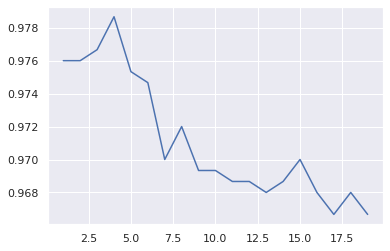

In [0]:
scores =[]
for k in range(1,20):
    NNH = KNeighborsClassifier(n_neighbors = k, weights = 'distance' )
    NNH.fit(X_train, Y_train)
    scores.append(NNH.score(X_test, Y_test))
plt.plot(range(1,20),scores)

**Guassian Bayes Algorithm**

/usr/local/lib/python3.6/dist-packages/sklearn/naive_bayes.py:206: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


GuassianNB Classification Report
               precision    recall  f1-score   support

           0       0.96      0.91      0.93      1360
           1       0.41      0.59      0.48       140

    accuracy                           0.88      1500
   macro avg       0.68      0.75      0.71      1500
weighted avg       0.90      0.88      0.89      1500

AxesSubplot(0.125,0.125;0.62x0.755)

Accuracy of Trainingset=0.88

Accuracy of Testset=0.88


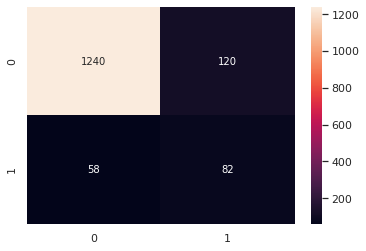

In [0]:
GN = GaussianNB()

GN.fit(X_train, Y_train)



GN_Ypred = GN.predict(X_test)

GN_Train_Score = GN.score(X_train, Y_train)
GN_Test_Score = GN.score(X_test, Y_test)

GN_CM = metrics.confusion_matrix(Y_test, GN_Ypred)

GN_CR_Report = metrics.classification_report(Y_test, GN_Ypred)

print("GuassianNB Classification Report\n", GN_CR_Report)
print(sns.heatmap(GN_CM, annot=True, fmt='2g'))

print("")

print("Accuracy of Trainingset=%.2f" %(GN_Train_Score))

print("")

print("Accuracy of Testset=%.2f" %(GN_Test_Score))

**Support Vector Machine Algorithm with different Kernals**

/usr/local/lib/python3.6/dist-packages/sklearn/utils/validation.py:760: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


SVM SVC Classification Report
               precision    recall  f1-score   support

           0       0.94      0.92      0.93      1360
           1       0.34      0.38      0.36       140

    accuracy                           0.87      1500
   macro avg       0.64      0.65      0.64      1500
weighted avg       0.88      0.87      0.88      1500

AxesSubplot(0.125,0.125;0.62x0.755)

Accuracy of Trainingset=0.87

Accuracy of Testset=0.87


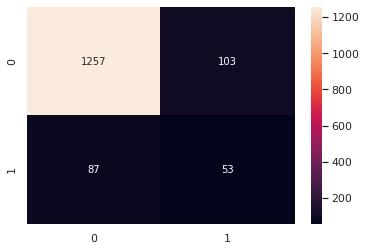

In [0]:
SV_Sig = svm.SVC(C=1.0, kernel='sigmoid', degree=3, gamma='auto')

SV_Sig.fit(X_train, Y_train)


SV_Sig_Train_Score = SV_Sig.score(X_train, Y_train)
SV_Sig_Test_Score = SV_Sig.score(X_test, Y_test)

SV_Sig_Ypred = SV_Sig.predict(X_test)

SV_Sig_CM = metrics.confusion_matrix(Y_test, SV_Sig_Ypred)

SV_Sig_CR_Report = metrics.classification_report(Y_test, SV_Sig_Ypred)

print("SVM SVC Classification Report\n", SV_Sig_CR_Report)
print(sns.heatmap(SV_Sig_CM, annot=True, fmt='2g'))

print("")

print("Accuracy of Trainingset=%.2f" %(SV_Sig_Train_Score))

print("")

print("Accuracy of Testset=%.2f" %(SV_Sig_Test_Score))

/usr/local/lib/python3.6/dist-packages/sklearn/utils/validation.py:760: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


SVM SVC Classification Report
               precision    recall  f1-score   support

           0       0.97      1.00      0.98      1360
           1       0.95      0.72      0.82       140

    accuracy                           0.97      1500
   macro avg       0.96      0.86      0.90      1500
weighted avg       0.97      0.97      0.97      1500

AxesSubplot(0.125,0.125;0.62x0.755)

Accuracy of Trainingset=0.98

Accuracy of Testset=0.97


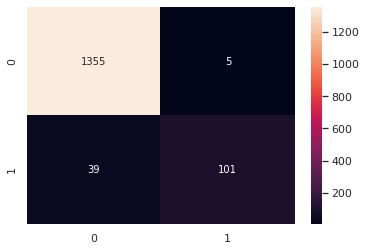

In [0]:
SV_Poly = svm.SVC(C=1.0, kernel='poly', degree=3, gamma='auto')

SV_Poly.fit(X_train, Y_train)


SV_Poly_Train_Score = SV_Poly.score(X_train, Y_train)
SV_Poly_Test_Score = SV_Poly.score(X_test, Y_test)

SV_Poly_Ypred = SV_Poly.predict(X_test)

SV_Poly_CM = metrics.confusion_matrix(Y_test, SV_Poly_Ypred)

SV_Poly_CR_Report = metrics.classification_report(Y_test, SV_Poly_Ypred)

print("SVM SVC Classification Report\n", SV_Poly_CR_Report)
print(sns.heatmap(SV_Poly_CM, annot=True, fmt='2g'))

print("")

print("Accuracy of Trainingset=%.2f" %(SV_Poly_Train_Score))

print("")

print("Accuracy of Testset=%.2f" %(SV_Poly_Test_Score))

/usr/local/lib/python3.6/dist-packages/sklearn/utils/validation.py:760: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


SVM SVC Classification Report
               precision    recall  f1-score   support

           0       0.98      1.00      0.99      1360
           1       0.97      0.81      0.88       140

    accuracy                           0.98      1500
   macro avg       0.97      0.90      0.93      1500
weighted avg       0.98      0.98      0.98      1500

AxesSubplot(0.125,0.125;0.62x0.755)

Accuracy of Trainingset=0.98

Accuracy of Testset=0.98


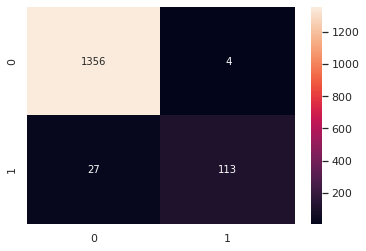

In [0]:
SV_rbf = svm.SVC(C=1.0, kernel='rbf', degree=3, gamma='auto')

SV_rbf.fit(X_train, Y_train)


SV_rbf_Train_Score = SV_rbf.score(X_train, Y_train)
SV_rbf_Test_Score = SV_rbf.score(X_test, Y_test)

SV_rbf_Ypred = SV_rbf.predict(X_test)

SV_rbf_CM = metrics.confusion_matrix(Y_test, SV_rbf_Ypred)

SV_rbf_CR_Report = metrics.classification_report(Y_test, SV_rbf_Ypred)

print("SVM SVC Classification Report\n", SV_rbf_CR_Report)
print(sns.heatmap(SV_rbf_CM, annot=True, fmt='2g'))

print("")

print("Accuracy of Trainingset=%.2f" %(SV_rbf_Train_Score))

print("")

print("Accuracy of Testset=%.2f" %(SV_rbf_Test_Score))

**Confusion Matrix for all above models**

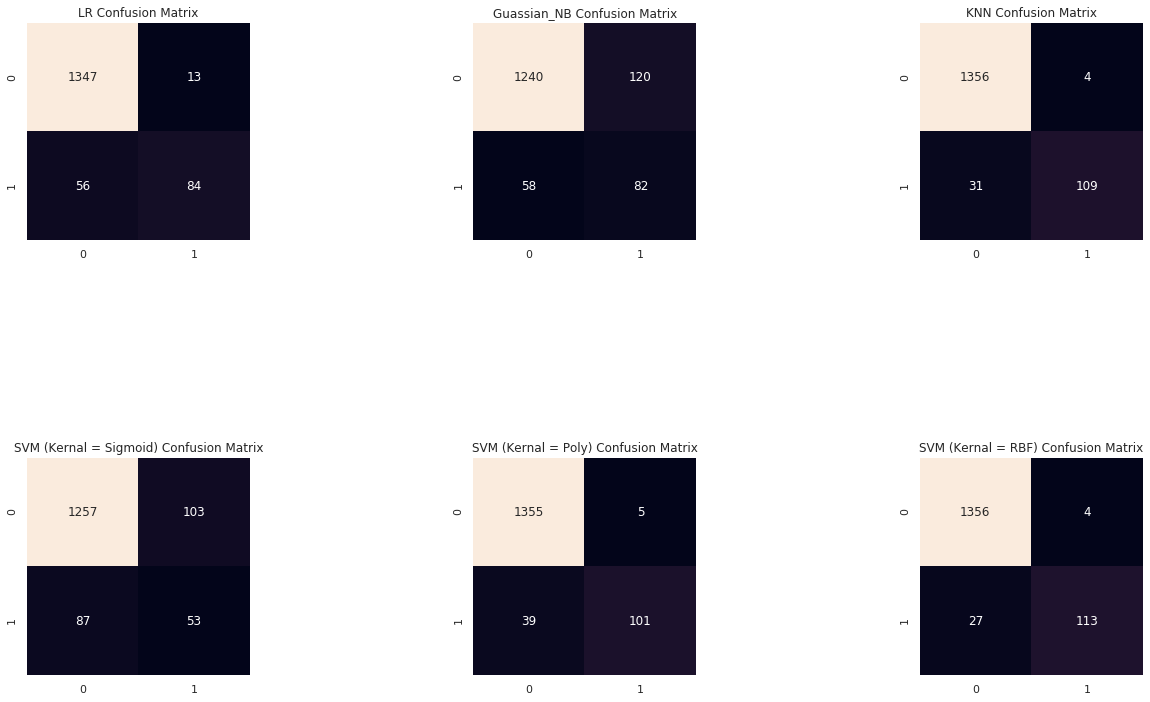

In [0]:
plt.figure(figsize = (20,20))

plt.subplots_adjust(wspace = 1, hspace = 1)


plt.subplot(3,3,1)
plt.title("LR Confusion Matrix")
sns.heatmap(Log_CM,annot=True,fmt="d",cbar=False, annot_kws={"size": 12})

plt.subplot(3,3,2)
plt.title("Guassian_NB Confusion Matrix")
sns.heatmap(GN_CM,annot=True,fmt="d",cbar=False, annot_kws={"size": 12})

plt.subplot(3,3,3)
plt.title("KNN Confusion Matrix")
sns.heatmap(KNN_CM,annot=True,fmt="d",cbar=False, annot_kws={"size": 12})


plt.subplot(3,3,4)
plt.title("SVM (Kernal = Sigmoid) Confusion Matrix")
sns.heatmap(SV_Sig_CM,annot=True,fmt="d",cbar=False, annot_kws={"size": 12})


plt.subplot(3,3,5)
plt.title("SVM (Kernal = Poly) Confusion Matrix")
sns.heatmap(SV_Poly_CM,annot=True,fmt="d",cbar=False, annot_kws={"size": 12})


plt.subplot(3,3,6)
plt.title("SVM (Kernal = RBF) Confusion Matrix")
sns.heatmap(SV_rbf_CM,annot=True,fmt="d",cbar=False, annot_kws={"size": 12})








**Accuracies Score for All above models**

In [0]:
Accuracies = pd.Series({'LR':Log_Test_Score,'GNB':GN_Test_Score,'KNN':KNN_Test_Score,'SVM_Sig':SV_Sig_Test_Score,'SVM_Poly':SV_Poly_Test_Score,'SVM_rbf':SV_rbf_Test_Score})
Accuracies.to_frame('scores')

,scores
LR,0.953333
GNB,0.881333
KNN,0.976667
SVM_Sig,0.873333
SVM_Poly,0.970667
SVM_rbf,0.979333


**Conclusion :-**

By Observing scores and confusion matrix of models, I conclude KNN is the best beacuase it gives highest no of TP and less no of FN with good accuracy score among Logistic, KNN and Naive Bayes models.

By conserding all models, SVM with Kernal RBF gives good results with best accuracy score.